In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully")

Libraries imported successfully


In [3]:
df = pd.read_csv("Titanic-Dataset.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
print("Shape:", df.shape)

Shape: (891, 12)


In [5]:
print("Columns:")
print(df.columns.tolist())

Columns:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [7]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [8]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [9]:
missing_values = df.isnull().sum()

print(missing_values)

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [10]:
missing_percentage = (
    df.isnull().mean() * 100
).round(2)

missing_percentage

PassengerId     0.00
Survived        0.00
Pclass          0.00
Name            0.00
Sex             0.00
Age            19.87
SibSp           0.00
Parch           0.00
Ticket          0.00
Fare            0.00
Cabin          77.10
Embarked        0.22
dtype: float64

In [11]:
quality_report = pd.DataFrame({
    "Column": df.columns,
    "Data_Type": df.dtypes.astype(str).values,
    "Missing_Values": df.isnull().sum().values,
    "Missing_Percentage": (
        df.isnull().mean().values * 100
    ).round(2),
    "Unique_Values": df.nunique().values
})

quality_report

,Column,Data_Type,Missing_Values,Missing_Percentage,Unique_Values
0,PassengerId,int64,0,0.00,891
1,Survived,int64,0,0.00,2
2,Pclass,int64,0,0.00,3
3,Name,object,0,0.00,891
4,Sex,object,0,0.00,2
5,Age,float64,177,19.87,88
6,SibSp,int64,0,0.00,7
7,Parch,int64,0,0.00,7
8,Ticket,object,0,0.00,681
9,Fare,float64,0,0.00,248


In [12]:
duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


In [13]:
df[df.duplicated()].head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked


In [14]:
messy_df = df.copy()

print("Original rows:", len(messy_df))

Original rows: 891


In [15]:
messy_df.loc[messy_df.index[:10], "Sex"] = "M"
messy_df.loc[messy_df.index[10:20], "Sex"] = "MALE"
messy_df.loc[messy_df.index[20:30], "Sex"] = "F"
messy_df.loc[messy_df.index[30:40], "Sex"] = "FEMALE"

messy_df["Sex"].value_counts(dropna=False)

Sex
male      556
female    295
M          10
MALE       10
F          10
FEMALE     10
Name: count, dtype: int64

In [16]:
messy_df.loc[messy_df.index[:10], "Age"] = np.nan
messy_df.loc[messy_df.index[10:15], "Fare"] = np.nan

messy_df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            186
SibSp            0
Parch            0
Ticket           0
Fare             5
Cabin          687
Embarked         2
dtype: int64

In [17]:
duplicate_sample = messy_df.iloc[:5].copy()

messy_df = pd.concat(
    [messy_df, duplicate_sample],
    ignore_index=True
)

print("Rows:", len(messy_df))
print("Duplicates:", messy_df.duplicated().sum())

Rows: 896
Duplicates: 5


In [18]:
messy_df.loc[messy_df.index[50], "Fare"] = 1000

messy_df["Fare"].describe()

count     891.000000
mean       33.346174
std        59.355333
min         0.000000
25%         7.910400
50%        14.454200
75%        31.137500
max      1000.000000
Name: Fare, dtype: float64

In [20]:
messy_df.to_csv(
    "messy_titanic.csv",
    index=False
)

print("Messy dataset saved successfully.")

Messy dataset saved successfully.


In [21]:
from IPython.display import FileLink
FileLink('messy_titanic.csv')

/Users/nishantpawar/messy_titanic.csv

In [22]:
df = pd.read_csv("messy_titanic.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",M,NaN,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",M,NaN,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",M,NaN,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",M,NaN,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",M,NaN,0,0,373450,8.0500,NaN,S


In [23]:
before_rows = len(df)

before_duplicates = df.duplicated().sum()

before_nulls = df.isnull().sum().sum()

print("BEFORE CLEANING")
print("----------------")
print("Rows:", before_rows)
print("Duplicate rows:", before_duplicates)
print("Total missing values:", before_nulls)

BEFORE CLEANING
----------------
Rows: 896
Duplicate rows: 5
Total missing values: 888


In [24]:
age_median = df["Age"].median()

df["Age"] = df["Age"].fillna(age_median)

print(
    "Missing Age after cleaning:",
    df["Age"].isnull().sum()
)

Missing Age after cleaning: 0


In [25]:
fare_median = df["Fare"].median()

df["Fare"] = df["Fare"].fillna(fare_median)

print(
    "Missing Fare after cleaning:",
    df["Fare"].isnull().sum()
)

Missing Fare after cleaning: 0


In [26]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          690
Embarked         2
dtype: int64

In [27]:
df = df.drop(columns=["Cabin"])

In [28]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       2
dtype: int64

In [29]:
duplicates_before = df.duplicated().sum()

df = df.drop_duplicates()

duplicates_after = df.duplicated().sum()

print("Duplicates before:", duplicates_before)
print("Duplicates after:", duplicates_after)
print(
    "Duplicates removed:",
    duplicates_before - duplicates_after
)

Duplicates before: 5
Duplicates after: 0
Duplicates removed: 5


In [30]:
df["Sex"].value_counts()

Sex
male      556
female    295
M          10
MALE       10
F          10
FEMALE     10
Name: count, dtype: int64

In [31]:
sex_mapping = {
    "male": "Male",
    "MALE": "Male",
    "M": "Male",
    "female": "Female",
    "FEMALE": "Female",
    "F": "Female"
}

df["Sex"] = df["Sex"].replace(sex_mapping)

df["Sex"].value_counts()

Sex
Male      576
Female    315
Name: count, dtype: int64

In [32]:
df["PassengerId"] = df["PassengerId"].astype(str)

df["Survived"] = df["Survived"].astype(int)

df["Pclass"] = df["Pclass"].astype(int)

df["Age"] = pd.to_numeric(
    df["Age"],
    errors="coerce"
)

df["Fare"] = pd.to_numeric(
    df["Fare"],
    errors="coerce"
)

df.dtypes

PassengerId     object
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Embarked        object
dtype: object

In [33]:
def detect_outliers_iqr(data, column):

    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[
        (data[column] < lower_bound) |
        (data[column] > upper_bound)
    ]

    return outliers, lower_bound, upper_bound

In [34]:
fare_outliers, lower, upper = detect_outliers_iqr(
    df,
    "Fare"
)

print("Lower Bound:", lower)
print("Upper Bound:", upper)
print("Number of Outliers:", len(fare_outliers))

Lower Bound: -26.687499999999996
Upper Bound: 65.6125
Number of Outliers: 117


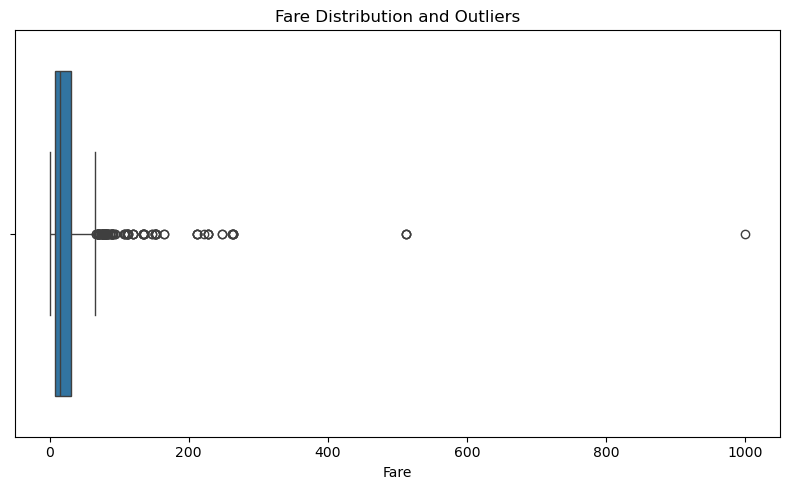

In [35]:
plt.figure(figsize=(8, 5))

sns.boxplot(x=df["Fare"])

plt.title("Fare Distribution and Outliers")
plt.xlabel("Fare")

plt.tight_layout()
plt.show()

In [36]:
Q1 = df["Fare"].quantile(0.25)
Q3 = df["Fare"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df["Fare"] = df["Fare"].clip(
    lower_bound,
    upper_bound
)

print("Fare outliers capped successfully.")

Fare outliers capped successfully.


In [37]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       2
dtype: int64


In [38]:
print(
    "Duplicate rows:",
    df.duplicated().sum()
)

Duplicate rows: 0


In [39]:
after_rows = len(df)

after_duplicates = df.duplicated().sum()

after_nulls = df.isnull().sum().sum()

print("AFTER CLEANING")
print("----------------")
print("Rows:", after_rows)
print("Duplicate rows:", after_duplicates)
print("Total missing values:", after_nulls)

AFTER CLEANING
----------------
Rows: 891
Duplicate rows: 0
Total missing values: 2


In [40]:
before_after = pd.DataFrame({
    "Metric": [
        "Row Count",
        "Duplicate Rows",
        "Total Missing Values"
    ],
    
    "Before Cleaning": [
        before_rows,
        before_duplicates,
        before_nulls
    ],
    
    "After Cleaning": [
        after_rows,
        after_duplicates,
        after_nulls
    ]
})

before_after

,Metric,Before Cleaning,After Cleaning
0,Row Count,896,891
1,Duplicate Rows,5,0
2,Total Missing Values,888,2


In [41]:
final_quality_report = pd.DataFrame({
    "Column": df.columns,
    "Data_Type": df.dtypes.astype(str).values,
    "Missing_Values": df.isnull().sum().values,
    "Missing_Percentage": (
        df.isnull().mean() * 100
    ).round(2).values,
    "Unique_Values": df.nunique().values
})

final_quality_report

,Column,Data_Type,Missing_Values,Missing_Percentage,Unique_Values
0,PassengerId,object,0,0.00,891
1,Survived,int64,0,0.00,2
2,Pclass,int64,0,0.00,3
3,Name,object,0,0.00,891
4,Sex,object,0,0.00,2
5,Age,float64,0,0.00,88
6,SibSp,int64,0,0.00,7
7,Parch,int64,0,0.00,7
8,Ticket,object,0,0.00,681
9,Fare,float64,0,0.00,204


In [42]:
display(df.head(10))

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",Male,28.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",Male,28.0,1,0,PC 17599,65.6125,C
2,3,1,3,"Heikkinen, Miss. Laina",Male,28.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Male,28.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",Male,28.0,0,0,373450,8.0500,S
5,6,0,3,"Moran, Mr. James",Male,28.0,0,0,330877,8.4583,Q
6,7,0,1,"McCarthy, Mr. Timothy J",Male,28.0,0,0,17463,51.8625,S
7,8,0,3,"Palsson, Master. Gosta Leonard",Male,28.0,3,1,349909,21.0750,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",Male,28.0,0,2,347742,11.1333,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",Male,28.0,1,0,237736,30.0708,C


In [44]:
df.to_csv(
    "cleaned_titanic.csv",
    index=False
)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


In [45]:
from IPython.display import FileLink
FileLink('cleaned_titanic.csv')

/Users/nishantpawar/cleaned_titanic.csv